# **1. Perkenalan Dataset**

## 1. Sumber dan Deskripsi Dataset

Dataset yang digunakan dalam proyek ini adalah **Student Performance Analytics Dataset** yang diperoleh dari platform Kaggle. Dataset ini berisi lebih dari 10.000 data siswa dengan berbagai atribut yang merepresentasikan performa akademik, kebiasaan belajar, serta faktor latar belakang yang berpotensi memengaruhi hasil belajar.

Setiap baris data merepresentasikan satu individu siswa dengan sejumlah fitur yang dapat dikelompokkan sebagai berikut:

* **Academic Performance**: nilai assignment, midterm, final exam, dan partisipasi
* **Study Behavior**: durasi belajar harian dan waktu tidur
* **Engagement**: tingkat kehadiran dan partisipasi kelas
* **Background Factors**: pendidikan orang tua, akses internet, dan kelas tambahan

Dataset ini juga menyediakan variabel target yang dapat digunakan dalam pemodelan machine learning, yaitu:

* **Overall Score** (numerik → regresi)
* **Grade (A–F)** (kategori → klasifikasi)

Dataset ini memiliki struktur yang bersih tanpa missing values sehingga dapat langsung digunakan dalam proses pemodelan tanpa tahap imputasi yang kompleks.

---

## 2. Tujuan Penggunaan Dataset

Dataset ini digunakan untuk membangun model machine learning yang bertujuan:

* Mengklasifikasikan performa siswa berdasarkan kategori nilai (Grade)
* Mengidentifikasi faktor-faktor yang paling berpengaruh terhadap performa akademik
* Menguji performa model melalui eksperimen yang terdokumentasi menggunakan MLflow

Pemilihan dataset ini didasarkan pada kompleksitas fitur yang cukup representatif untuk studi kasus machine learning, serta kemudahan dalam integrasi ke dalam pipeline MLOps.


# **2. Import Library**

## 2. Import Library

Pada tahap ini dilakukan proses impor pustaka Python yang diperlukan untuk mendukung seluruh pipeline machine learning, mulai dari pengolahan data, pemodelan, hingga pencatatan eksperimen menggunakan MLflow.

Library yang digunakan meliputi:

* **pandas** → digunakan untuk manipulasi dan analisis data berbasis tabel
* **numpy** → digunakan untuk operasi numerik dan pembuatan range parameter
* **scikit-learn** → digunakan untuk proses pemodelan, pembagian data (train-test split), serta evaluasi model
* **mlflow** → digunakan untuk melakukan tracking eksperimen, pencatatan parameter, metrik, dan model

Berikut adalah library yang diimpor:



Import library ini menjadi fondasi dalam membangun pipeline machine learning yang terstruktur dan dapat direproduksi, terutama dalam konteks penerapan MLOps.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
! pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 137.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 163.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 118.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.2/866.2 kB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [8]:
import pandas as pd
import numpy as np

# visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import mlflow
import mlflow.sklearn

# **3. Memuat Dataset**

In [42]:
df = pd.read_csv('/content/drive/MyDrive/KERJAAN/MACHINE LEARNING/SMSML DIcoding/student_performance_data.csv')

In [ ]:
# menampilkan semua kolom
pd.set_option('display.max_columns', None)
# melihat sample data
df.head()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


In [ ]:
# melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  int64  
 1   gender                 10000 non-null  object 
 2   study_hours_per_day    10000 non-null  float64
 3   attendance_percentage  10000 non-null  float64
 4   assignment_score       10000 non-null  float64
 5   midterm_score          10000 non-null  float64
 6   final_exam_score       10000 non-null  float64
 7   participation_score    10000 non-null  float64
 8   internet_access        10000 non-null  object 
 9   extra_classes          10000 non-null  object 
 10  parent_education       10000 non-null  object 
 11  sleep_hours            10000 non-null  float64
 12  overall_score          10000 non-null  float64
 13  grade                  10000 non-null  object 
dtypes: float64(8), int64(1), object(5)
memory usage: 1.1+ M

In [ ]:
# melihat missing value
df.isnull().sum()

,0
student_id,0
gender,0
study_hours_per_day,0
attendance_percentage,0
assignment_score,0
midterm_score,0
final_exam_score,0
participation_score,0
internet_access,0
extra_classes,0


In [ ]:
# melihat duplikat data
df.duplicated().sum()

np.int64(0)

In [ ]:
# statistik deskriptif
df.describe()

,student_id,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,104999.50000,5.467825,70.493817,64.717809,62.322568,64.979987,55.103202,6.505165,63.826901
std,2886.89568,2.594134,17.295607,20.052779,21.710555,20.216141,25.955949,1.458246,10.230977
min,100000.00000,1.000000,40.000000,30.000000,25.000000,30.010000,10.000000,4.000000,33.263500
25%,102499.75000,3.220000,55.640000,47.320000,43.515000,47.400000,32.955000,5.220000,56.528125
50%,104999.50000,5.420000,70.780000,64.770000,62.050000,65.210000,55.055000,6.520000,63.780750
75%,107499.25000,7.740000,85.200000,81.760000,81.227500,82.500000,77.760000,7.792500,71.163125
max,109999.00000,10.000000,100.000000,99.990000,100.000000,100.000000,99.990000,9.000000,96.879500


In [ ]:
# melihat nilai untuk kolom gender
df['gender'].value_counts()

,count
gender,
Male,5013
Female,4987


In [ ]:
# melihat nilai untuk kolom internet_access
df['internet_access'].value_counts()

,count
internet_access,
Yes,5061
No,4939


In [ ]:
# melihat nilai untuk kolom extra_classes
df['extra_classes'].value_counts()

,count
extra_classes,
Yes,5087
No,4913


In [ ]:
# melihat nilai untuk kolom parent_education
df['parent_education'].value_counts()

,count
parent_education,
High School,2528
Bachelor,2527
Master,2487
PhD,2458


In [ ]:
# melihat nilai untuk kolom grade
df['grade'].value_counts()  

,count
grade,
C,5073
B,2704
D,2008
A,154
F,61


### Visualisasi

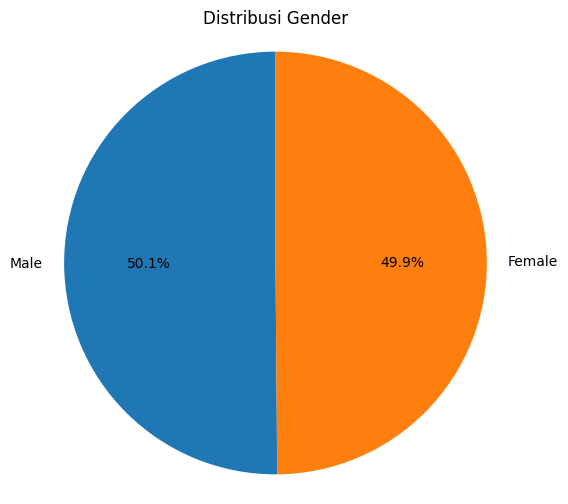

In [10]:
gender_counts = df["gender"].value_counts()

# plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribusi Gender")
plt.axis('equal') 
plt.show()

In [13]:
df["study_hours_category"] = pd.cut(
    df["study_hours_per_day"],
    bins=[1, 3, 5, 7, 9, 10],
    labels=["very_low", "low", "medium", "high", "very_high"],
    include_lowest=True
)

In [14]:
df["study_hours_category"].value_counts()

,count
study_hours_category,
very_low,2261
low,2252
medium,2223
high,2170
very_high,1094


/tmp/ipykernel_437/4273888328.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='grade', y=col, palette=palette_grade, ax=ax)
/tmp/ipykernel_437/4273888328.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='grade', y=col, palette=palette_grade, ax=ax)
/tmp/ipykernel_437/4273888328.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='grade', y=col, palette=palette_grade, ax=ax)
/tmp/ipykernel_437/4273888328.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remov

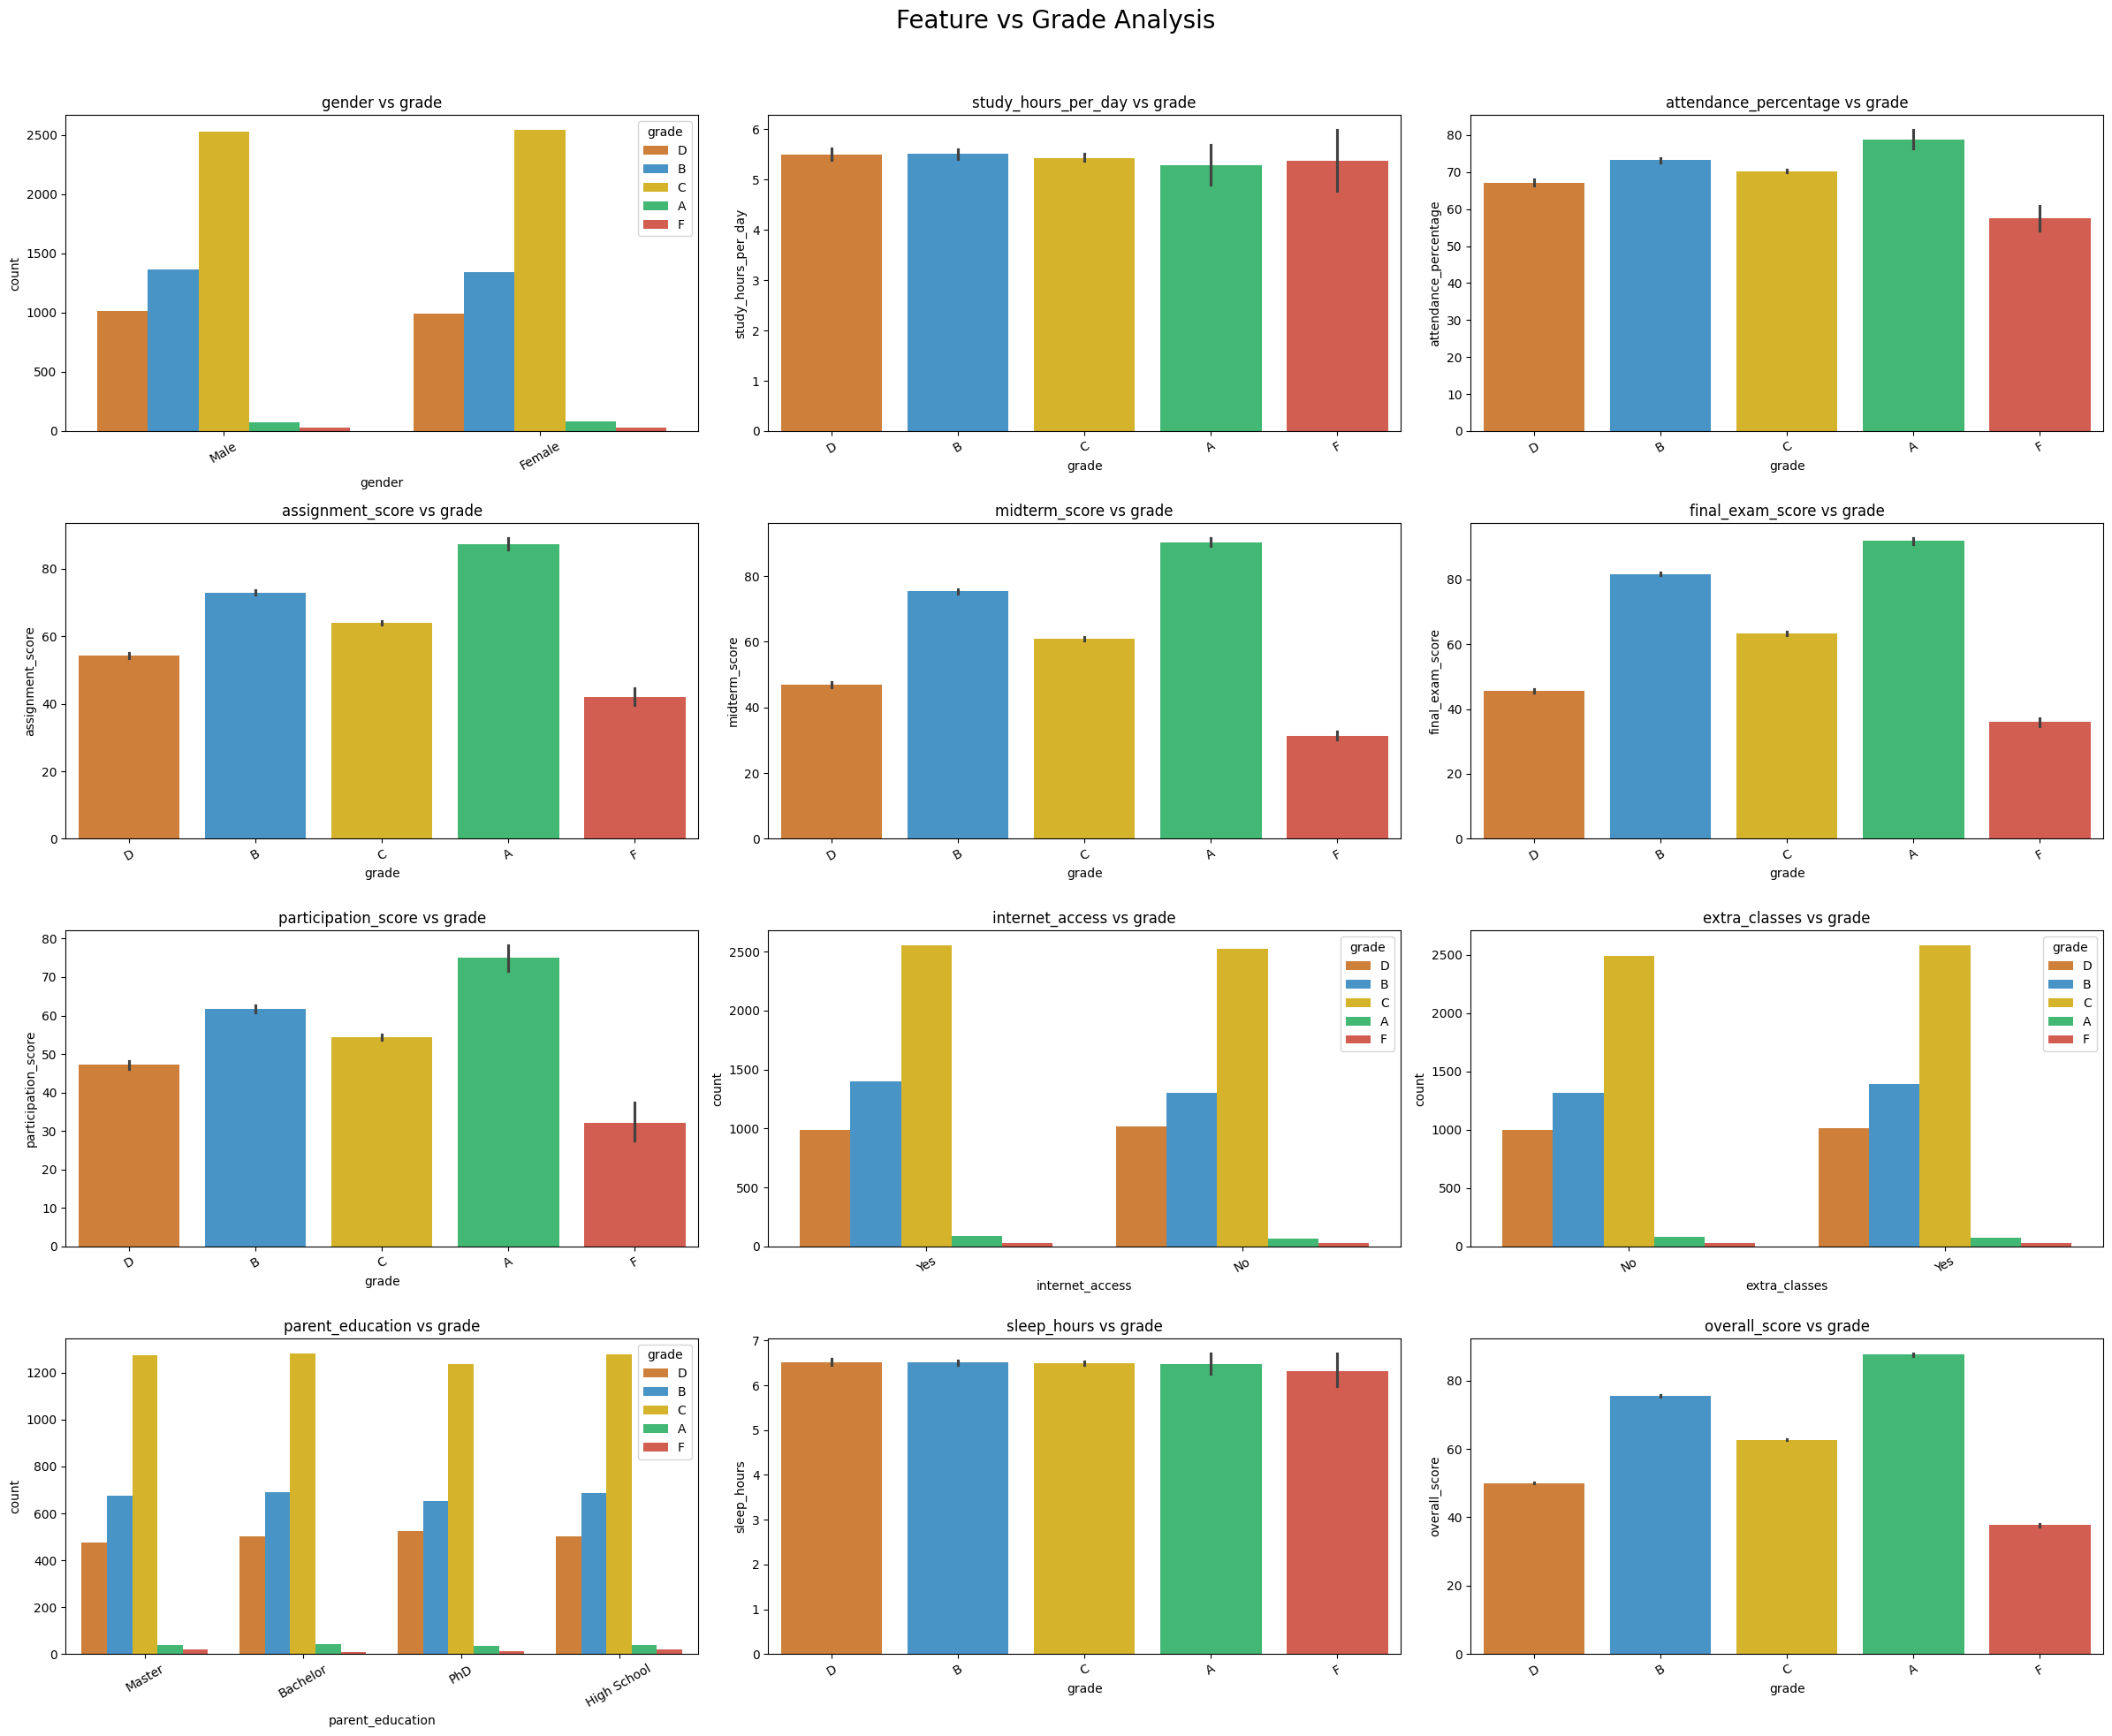

In [24]:

palette_grade = {
    "A": "#2ecc71",
    "B": "#3498db",
    "C": "#f1c40f",
    "D": "#e67e22",
    "F": "#e74c3c"
}

fig, axes = plt.subplots(4, 3, figsize=(24, 20))
fig.suptitle('Feature vs Grade Analysis', fontsize=20)

features = [
    'gender',
    'study_hours_per_day',
    'attendance_percentage',
    'assignment_score',
    'midterm_score',
    'final_exam_score',
    'participation_score',
    'internet_access',
    'extra_classes',
    'parent_education',
    'sleep_hours',
    'overall_score'
]

for ax, col in zip(axes.flatten(), features):

    if df[col].dtype == "object":
        sns.countplot(data=df, x=col, hue='grade', palette=palette_grade, ax=ax)
    else:
        sns.barplot(data=df, x='grade', y=col, palette=palette_grade, ax=ax)

    ax.set_title(f"{col} vs grade")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [43]:
df = df.drop(columns=["overall_score", "student_id"])

In [44]:
numeric = df.select_dtypes(include=["int64", "float64"]).columns
categoric = df.select_dtypes(include=["object"]).columns
# melihat nilai untuk tiap kategori baik numerik maupun kategorik

print("jumlah kolom numerik", len(numeric))
print("jumlah kolom kategorik", len(categoric))

jumlah kolom numerik 7
jumlah kolom kategorik 5


In [45]:
import numpy as np
import pandas as pd

print(f'Jumlah baris: {len(df)}')

outlier = []
low_lim = []
high_lim = []

for col in numeric:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    low_limit = Q1 - 1.5 * IQR
    high_limit = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < low_limit) | (df[col] > high_limit)).sum()

    outlier.append(outlier_count)
    low_lim.append(low_limit)
    high_lim.append(high_limit)

result = pd.DataFrame({
    "Column": numeric,
    "Lower Limit": low_lim,
    "Upper Limit": high_lim,
    "Outlier Count": outlier
})

result

Jumlah baris: 10000


,Column,Lower Limit,Upper Limit,Outlier Count
0,study_hours_per_day,-3.56000,14.52000,0
1,attendance_percentage,11.30000,129.54000,0
2,assignment_score,-4.34000,133.42000,0
3,midterm_score,-13.05375,137.79625,0
4,final_exam_score,-5.25000,135.15000,0
5,participation_score,-34.25250,144.96750,0
6,sleep_hours,1.36125,11.65125,0


In [46]:
mask = np.zeros(len(df), dtype=bool)

for col in numeric:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR

    mask |= (df[col] < low) | (df[col] > high)

print("Total baris mengandung outlier:", mask.sum())

Total baris mengandung outlier: 0


In [41]:
# Cek Outlier
print(f'Jumlah baris: {len(df)}')

outlier = []
no_outlier = []
is_outlier = []
low_lim = []
high_lim = []

filtered_entries = np.array([True] * len(df))
for col in numeric:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    low_limit = Q1 - (IQR * 1.5)
    high_limit = Q3 + (IQR * 1.5)

    # mulai filter outlier
    filter_outlier = ((df[col] >= low_limit) & (df[col] <= high_limit))
    outlier.append(len(df[~filter_outlier]))
    no_outlier.append(len(df[filter_outlier]))
    is_outlier.append(df[col][~filter_outlier].any())
    low_lim.append(low_limit)
    high_lim.append(high_limit)

    filtered_entries = ((df[col] >= low_limit) & (df[col] <= high_limit)) & filtered_entries

print("Outlier All Data :", len(df[~filtered_entries]))
print("Not Outlier All Data :", len(df[filtered_entries]))
print()

# Pastikan numeric diubah ke list jika masih berupa Index
pd.DataFrame({
    "Column Name": list(numeric),
    "is Outlier": is_outlier,
    "Lower Limit": low_lim,
    "Upper Limit": high_lim,
    "Outlier": outlier,
    "No Outlier": no_outlier
})

Jumlah baris: 10000
Outlier All Data : 0
Not Outlier All Data : 10000



,Column Name,is Outlier,Lower Limit,Upper Limit,Outlier,No Outlier
0,study_hours_per_day,False,-3.480267,3.489654,0,10000
1,attendance_percentage,False,-3.422648,3.414112,0,10000
2,assignment_score,False,-3.443975,3.426240,0,10000
3,midterm_score,False,-3.472048,3.476533,0,10000
4,final_exam_score,False,-3.474130,3.471163,0,10000
5,participation_score,False,-3.442763,3.462358,0,10000
6,sleep_hours,False,-3.527644,3.529132,0,10000


### Analisis Outlier

Berdasarkan metode Interquartile Range (IQR), tidak ditemukan outlier pada seluruh fitur numerik dalam dataset. Hal ini ditunjukkan oleh jumlah data yang berada di luar batas bawah dan atas (lower dan upper limit) yang bernilai nol untuk setiap fitur.

Kondisi ini menunjukkan bahwa dataset memiliki distribusi yang relatif stabil dan tidak mengandung nilai ekstrem yang signifikan. Oleh karena itu, tidak dilakukan proses penghapusan outlier agar informasi data tetap terjaga.
